<a href="https://colab.research.google.com/github/Chitlangia-Vedant/Audio-Classification/blob/main/audio_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

!pip install -q librosa soundfile scikit-learn tensorflow keras \
                matplotlib seaborn pandas numpy tqdm keras-tuner
print('✅ All packages installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.1 MB/s eta 0:00:00
✅ All packages installed


In [ ]:

from google.colab import drive, files
import os, shutil

drive.mount('/content/drive')

os.makedirs('/root/.kaggle', exist_ok=True)
KAGGLE_JSON_PATH = '/content/drive/MyDrive/kaggle.json'

if os.path.exists(KAGGLE_JSON_PATH):
    shutil.copy(KAGGLE_JSON_PATH, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('✅ kaggle.json loaded from Drive')
else:
    print('⚠️  Upload your kaggle.json:')
    uploaded = files.upload()
    shutil.move(list(uploaded.keys())[0], '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print('✅ kaggle.json saved')

Mounted at /content/drive
⚠️  Upload your kaggle.json:


Saving kaggle.json to kaggle.json
✅ kaggle.json saved


Raw shape: (710, 13)
                      filename  deaths_binary  false_alarm  potential_death
0   911_first6sec/call_2_0.wav              1          0.0              1.0
1   911_first6sec/call_8_0.wav              1          0.0              1.0
2   911_first6sec/call_9_0.wav              0          1.0              0.0
3  911_first6sec/call_10_0.wav              1          0.0              1.0
4  911_first6sec/call_11_0.wav              0          1.0              0.0
5  911_first6sec/call_12_0.wav              1          0.0              1.0
6  911_first6sec/call_13_0.wav              1          0.0              1.0
7  911_first6sec/call_15_0.wav              1          0.0              1.0

Label distribution (deaths_binary):
deaths_binary
0    290
1    420
Name: count, dtype: int64


In [ ]:
import os

DATA_DIR = '/content/911_data'
os.makedirs(DATA_DIR, exist_ok=True)

!kaggle datasets download -d louisteitelbaum/911-recordings-first-6-seconds \
        -p {DATA_DIR} --unzip

# Quick directory overview
for root, dirs, fnames in os.walk(DATA_DIR):
    level = root.replace(DATA_DIR, '').count(os.sep)
    if level > 2: continue
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in sorted(fnames)[:5]:
        print(f'{indent}  {f}')
    if len(fnames) > 5:
        print(f'{indent}  ... +{len(fnames)-5} more')

Dataset URL: https://www.kaggle.com/datasets/louisteitelbaum/911-recordings-first-6-seconds
License(s): CC0-1.0
100% 318M/318M [00:01<00:00, 263MB/s]

911_data/
  911_first6sec/
    911_metadata.csv
    call_100_0.wav
    call_101_0.wav
    call_102_0.wav
    call_103_0.wav
    ... +703 more


In [ ]:
import pandas as pd
import numpy as np
import os

META_CSV  = '/content/911_data/911_first6sec/911_metadata.csv'
FILE_COL  = 'filename'
LABEL_COL = 'deaths_binary'

df = pd.read_csv(META_CSV)
print(f'Raw shape: {df.shape}')
print(df[[FILE_COL, LABEL_COL, 'false_alarm', 'potential_death']].head(8))
print(f'\nLabel distribution (deaths_binary):')
print(df[LABEL_COL].value_counts().sort_index())

Raw shape: (710, 13)
                      filename  deaths_binary  false_alarm  potential_death
0   911_first6sec/call_2_0.wav              1          0.0              1.0
1   911_first6sec/call_8_0.wav              1          0.0              1.0
2   911_first6sec/call_9_0.wav              0          1.0              0.0
3  911_first6sec/call_10_0.wav              1          0.0              1.0
4  911_first6sec/call_11_0.wav              0          1.0              0.0
5  911_first6sec/call_12_0.wav              1          0.0              1.0
6  911_first6sec/call_13_0.wav              1          0.0              1.0
7  911_first6sec/call_15_0.wav              1          0.0              1.0

Label distribution (deaths_binary):
deaths_binary
0    290
1    420
Name: count, dtype: int64


Missing audio files : 0/710
✅ Clean dataset: 707 samples

Label distribution:
deaths_binary
0    289
1    418
Name: count, dtype: int64


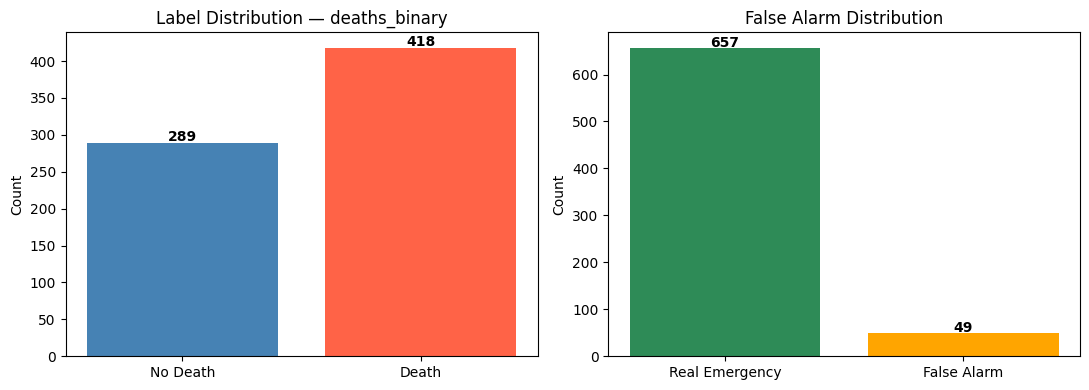

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── Drop missing, cast label, build absolute paths ────────────────────────────
df.dropna(subset=[FILE_COL, LABEL_COL], inplace=True)
df[LABEL_COL] = df[LABEL_COL].astype(int)
df['filepath'] = df[FILE_COL].apply(
    lambda p: os.path.join('/content/911_data', p)
)

# ── Verify files exist ────────────────────────────────────────────────────────
df['file_exists'] = df['filepath'].apply(os.path.exists)
missing = (~df['file_exists']).sum()
print(f'Missing audio files : {missing}/{len(df)}')
df = df[df['file_exists']].copy()

# ── De-duplicate ──────────────────────────────────────────────────────────────
df.drop_duplicates(subset=['filepath'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'✅ Clean dataset: {len(df)} samples')
vc = df[LABEL_COL].value_counts().sort_index()
print(f'\nLabel distribution:\n{vc}')

CLASS_NAMES = ['No Death', 'Death']
NUM_CLASSES = 2

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(['No Death', 'Death'], vc.values,
            color=['steelblue', 'tomato'])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[0].set_title('Label Distribution — deaths_binary')
axes[0].set_ylabel('Count')

fa_vc = df['false_alarm'].value_counts().sort_index()
axes[1].bar(['Real Emergency', 'False Alarm'], fa_vc.values,
            color=['seagreen', 'orange'])
for i, v in enumerate(fa_vc.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')
axes[1].set_title('False Alarm Distribution')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
import librosa
import warnings
from tqdm import tqdm
warnings.filterwarnings('ignore')

SR       = 16000
DURATION = 6.0
N_MFCC   = 40
HOP_LEN  = 512
MAX_LEN  = int(SR * DURATION / HOP_LEN) + 1
INPUT_SHAPE = (MAX_LEN, N_MFCC)

print(f'Config → SR={SR} | DURATION={DURATION}s | N_MFCC={N_MFCC} | MAX_LEN={MAX_LEN}')

def pad_or_trim(arr, target):
    if arr.shape[1] < target:
        arr = np.pad(arr, ((0,0),(0,target-arr.shape[1])), mode='constant')
    return arr[:, :target]

def extract_sequence(filepath):
    try:
        y, sr = librosa.load(filepath, sr=SR, duration=DURATION, mono=True)
        if len(y) < SR // 10:
            return None
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC, hop_length=HOP_LEN)
        return pad_or_trim(mfcc, MAX_LEN).T
    except:
        return None

print('\nExtracting MFCC sequences...')
seq_feats, valid_idx = [], []

for i, row in tqdm(df.iterrows(), total=len(df)):
    s = extract_sequence(row['filepath'])
    if s is not None:
        seq_feats.append(s)
        valid_idx.append(i)

df_valid = df.loc[valid_idx].reset_index(drop=True)
X_seq    = np.array(seq_feats, dtype=np.float32)
y_enc    = df_valid[LABEL_COL].values

print(f'\n✅ Valid samples : {len(df_valid)}')
print(f'   X_seq shape  : {X_seq.shape}')
print(f'   Class balance: {np.bincount(y_enc)}')

Config → SR=16000 | DURATION=6.0s | N_MFCC=40 | MAX_LEN=188

Extracting MFCC sequences...


100%|██████████| 707/707 [00:29<00:00, 23.98it/s]


✅ Valid samples : 707
   X_seq shape  : (707, 188, 40)
   Class balance: [289 418]


In [ ]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

idx = np.arange(len(df_valid))

# 70 / 15 / 15 stratified split
idx_tr, idx_tmp = train_test_split(idx, test_size=0.30, random_state=SEED,
                                   stratify=y_enc)
idx_val, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED,
                                   stratify=y_enc[idx_tmp])

X_tr_s, X_val_s, X_te_s = X_seq[idx_tr], X_seq[idx_val], X_seq[idx_te]
y_tr, y_val, y_te        = y_enc[idx_tr], y_enc[idx_val], y_enc[idx_te]

# Per-feature normalisation (fit on train only)
mu = X_tr_s.mean(axis=(0, 1), keepdims=True)
sd = X_tr_s.std(axis=(0, 1),  keepdims=True) + 1e-8
X_tr_s  = (X_tr_s  - mu) / sd
X_val_s = (X_val_s - mu) / sd
X_te_s  = (X_te_s  - mu) / sd

INPUT_SHAPE = (MAX_LEN, N_MFCC)

# Class weights for imbalance
cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
class_weights = dict(enumerate(cw))

print(f'Train : {len(y_tr)}  |  Val : {len(y_val)}  |  Test : {len(y_te)}')
print(f'Train class balance : {np.bincount(y_tr)}')
print(f'Val   class balance : {np.bincount(y_val)}')
print(f'Test  class balance : {np.bincount(y_te)}')
print(f'Class weights       : {class_weights}')
print(f'Input shape         : {INPUT_SHAPE}')

Train : 494  |  Val : 106  |  Test : 107
Train class balance : [202 292]
Val   class balance : [43 63]
Test  class balance : [44 63]
Class weights       : {0: np.float64(1.2227722772277227), 1: np.float64(0.8458904109589042)}
Input shape         : (188, 40)


In [ ]:
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_curve, auc,
    average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns

results_log = {}

def evaluate_model(model_name, y_true, y_pred, y_proba=None, history=None):
    acc  = accuracy_score(y_true, y_pred)
    rep  = classification_report(y_true, y_pred,
                                 target_names=['No Death','Death'],
                                 output_dict=True)
    f1_w = rep['weighted avg']['f1-score']
    f1_1 = rep['Death']['f1-score']

    roc = None
    if y_proba is not None:
        try:
            proba_pos = y_proba[:, 1] if y_proba.ndim == 2 else y_proba
            roc = roc_auc_score(y_true, proba_pos)
        except:
            roc = None

    results_log[model_name] = {
        'Accuracy': acc, 'F1 Weighted': f1_w,
        'F1 Death': f1_1, 'ROC-AUC': roc
    }

    print(f'\n{"="*58}')
    print(f'  Model         : {model_name}')
    print(f'  Accuracy      : {acc:.4f}')
    print(f'  F1 (weighted) : {f1_w:.4f}')
    print(f'  F1 (Death cls): {f1_1:.4f}')
    if roc: print(f'  ROC-AUC       : {roc:.4f}')
    print(f'{"="*58}')
    print(classification_report(y_true, y_pred,
                                target_names=['No Death','Death']))

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ncols = 3 if history else 2
    fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 4))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Death','Death'],
                yticklabels=['No Death','Death'], ax=axes[0])
    axes[0].set_title(f'{model_name} — Raw CM')
    axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='OrRd',
                xticklabels=['No Death','Death'],
                yticklabels=['No Death','Death'], ax=axes[1])
    axes[1].set_title(f'{model_name} — Normalised CM')
    axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

    if history:
        ep = range(1, len(history.history['accuracy']) + 1)
        axes[2].plot(ep, history.history['accuracy'],     label='Train Acc')
        axes[2].plot(ep, history.history['val_accuracy'], label='Val Acc')
        axes[2].plot(ep, history.history['loss'],     '--', label='Train Loss')
        axes[2].plot(ep, history.history['val_loss'], '--', label='Val Loss')
        axes[2].set_title('Training Curves')
        axes[2].set_xlabel('Epoch')
        axes[2].legend(fontsize=8)

    plt.suptitle(model_name, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    return acc, f1_w, roc

print('✅ Evaluation helper ready')

✅ Evaluation helper ready


Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 188, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 188, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 188, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 94, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 94, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 47, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 256)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 169,921 (663.75 KB)

 Trainable params: 169,537 (662.25 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 336ms/step - accuracy: 0.5020 - auc: 0.4855 - loss: 1.1908 - val_accuracy: 0.5755 - val_auc: 0.4922 - val_loss: 0.6828 - learning_rate: 0.0010
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5324 - auc: 0.5370 - loss: 0.8062 - val_accuracy: 0.6038 - val_auc: 0.5170 - val_loss: 0.6776 - learning_rate: 0.0010
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5830 - auc: 0.6187 - loss: 0.6858 - val_accuracy: 0.5943 - val_auc: 0.5330 - val_loss: 0.6758 - learning_rate: 0.0010
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5648 - auc: 0.6068 - loss: 0.6817 - val_accuracy: 0.5755 - val_auc: 0.5338 - val_loss: 0.6734 - learning_rate: 0.0010
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5931 - auc: 0.6813 - loss: 0.6398 - val_accuracy: 0.5849 - val_auc: 0.5155 - val_loss: 0.6786 - learning_rate: 0.0010
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6032 - auc: 0.6669

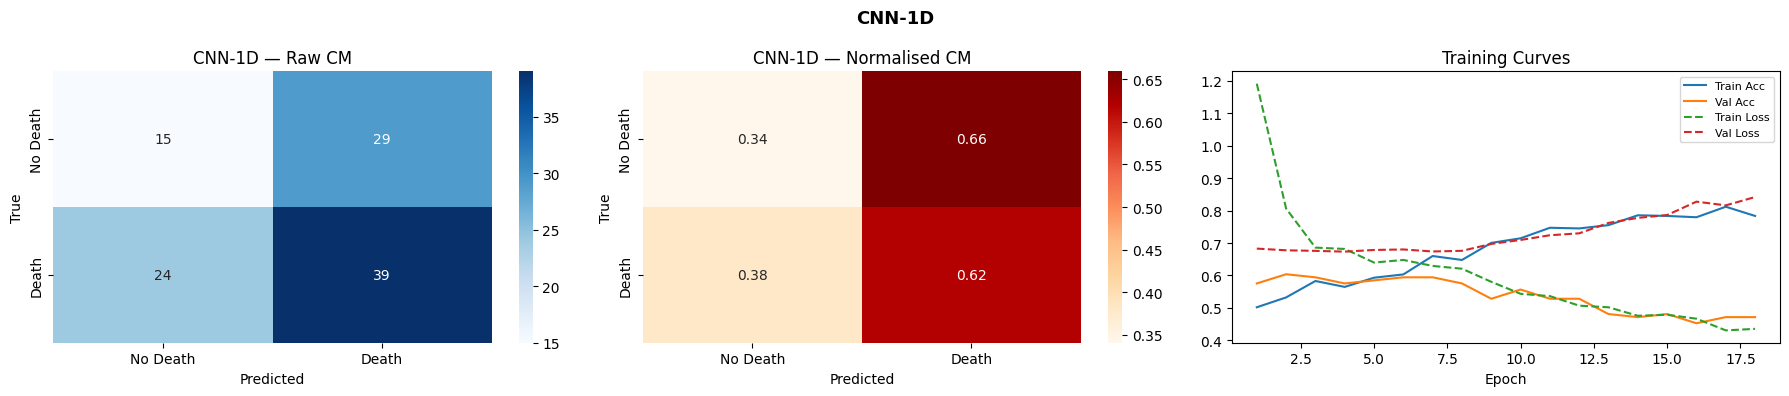

(0.5046728971962616, 0.49920621345337113, np.float64(0.47799422799422797))

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

EPOCHS     = 50
BATCH_SIZE = 32

def build_cnn1d(input_shape):
    inp = keras.Input(shape=input_shape)
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv1D(256, 3, activation='relu', padding='same')(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='CNN1D')
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

cnn_model = build_cnn1d(INPUT_SHAPE)
cnn_model.summary()

cb_cnn = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=8,
                                  restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=4, min_lr=1e-6, verbose=1)
]

history_cnn = cnn_model.fit(
    X_tr_s, y_tr,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_cnn, verbose=1
)

proba_cnn  = cnn_model.predict(X_te_s).ravel()
pred_cnn   = (proba_cnn >= 0.5).astype(int)
proba_cnn2 = np.column_stack([1 - proba_cnn, proba_cnn])
evaluate_model('CNN-1D', y_te, pred_cnn, proba_cnn2, history=history_cnn)

Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 188, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 188, 256)       │       173,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 188, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 345,729 (1.32 MB)

 Trainable params: 345,729 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - accuracy: 0.5931 - auc: 0.5562 - loss: 0.6924 - val_accuracy: 0.5660 - val_auc: 0.5478 - val_loss: 0.6808 - learning_rate: 5.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.5911 - auc: 0.5942 - loss: 0.6815 - val_accuracy: 0.5755 - val_auc: 0.5694 - val_loss: 0.6823 - learning_rate: 5.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.6174 - auc: 0.6580 - loss: 0.6615 - val_accuracy: 0.5377 - val_auc: 0.5509 - val_loss: 0.6901 - learning_rate: 5.0000e-04
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6215 - auc: 0.6931 - loss: 0.6459 - val_accuracy: 0.5472 - val_auc: 0.5524 - val_loss: 0.6945 - learning_rate: 5.0000e-04
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 953ms/step - accuracy: 0.7130 - auc: 0.7798 - loss: 0.6073
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
16/16 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.6903 - auc: 0.7606 - loss: 

3/4 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 597ms/step

  Model         : BiLSTM
  Accuracy      : 0.5234
  F1 (weighted) : 0.5225
  F1 (Death cls): 0.5984
  ROC-AUC       : 0.4848
              precision    recall  f1-score   support

    No Death       0.42      0.41      0.41        44
       Death       0.59      0.60      0.60        63

    accuracy                           0.52       107
   macro avg       0.51      0.51      0.51       107
weighted avg       0.52      0.52      0.52       107



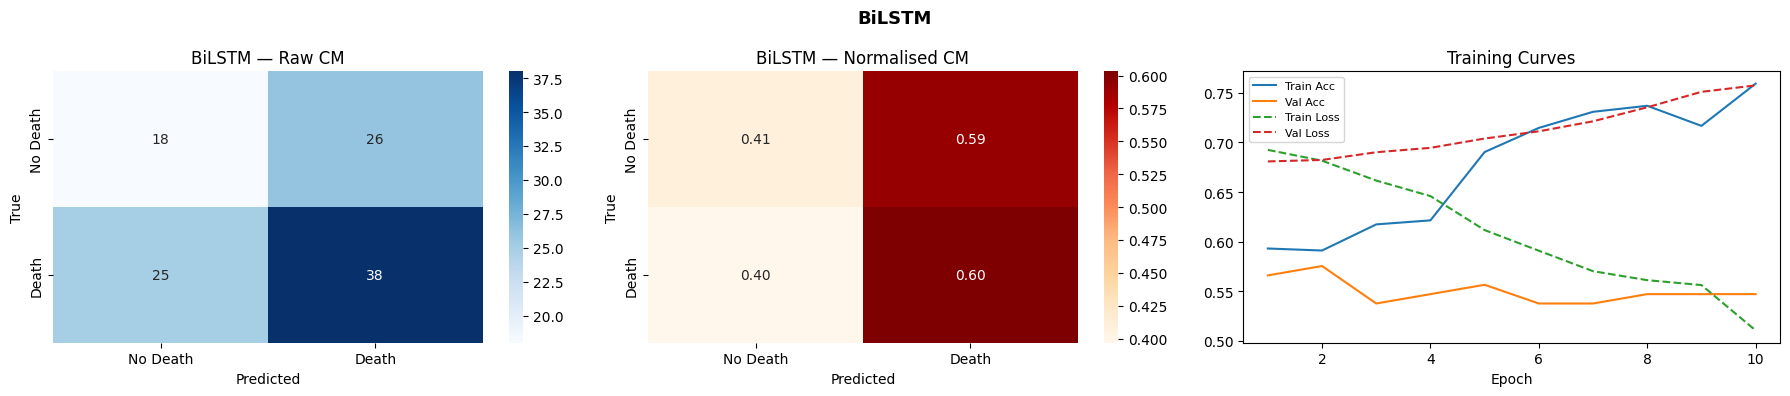

(0.5233644859813084, 0.5225017191897098, np.float64(0.48484848484848486))

In [ ]:
def build_bilstm(input_shape):
    inp = keras.Input(shape=input_shape)
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True,
                        dropout=0.2, recurrent_dropout=0.1))(inp)
    x = layers.Dropout(0.3)(x)
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=False, dropout=0.2))(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='BiLSTM')
    model.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

bilstm_model = build_bilstm(INPUT_SHAPE)
bilstm_model.summary()

cb_lstm = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=8,
                                  restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=4, min_lr=1e-6, verbose=1)
]

history_lstm = bilstm_model.fit(
    X_tr_s, y_tr,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_lstm, verbose=1
)

proba_lstm  = bilstm_model.predict(X_te_s).ravel()
pred_lstm   = (proba_lstm >= 0.5).astype(int)
proba_lstm2 = np.column_stack([1 - proba_lstm, proba_lstm])
evaluate_model('BiLSTM', y_te, pred_lstm, proba_lstm2, history=history_lstm)

Model: "CNN_BiLSTM_Hybrid"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 188, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 188, 64)        │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 188, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 94, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 94, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 94, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 47, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 47, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 490,689 (1.87 MB)

 Trainable params: 490,305 (1.87 MB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4373 - auc: 0.4195 - loss: 0.7306
Epoch 1: val_auc improved from None to 0.53119, saving model to /content/best_hybrid.keras

Epoch 1: finished saving model to /content/best_hybrid.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 8s 92ms/step - accuracy: 0.4757 - auc: 0.4451 - loss: 0.7199 - val_accuracy: 0.5943 - val_auc: 0.5312 - val_loss: 0.6900 - learning_rate: 5.0000e-04
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5793 - auc: 0.6117 - loss: 0.6979
Epoch 2: val_auc did not improve from 0.53119
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.5445 - auc: 0.5593 - loss: 0.7021 - val_accuracy: 0.5943 - val_auc: 0.5286 - val_loss: 0.6891 - learning_rate: 5.0000e-04
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5873 - auc: 0.6551 - loss: 0.6819
Epoch 3: val_auc did not improve from 0.53119
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5911 - auc: 0.6449 - loss: 0.6781 - val_accuracy: 0.

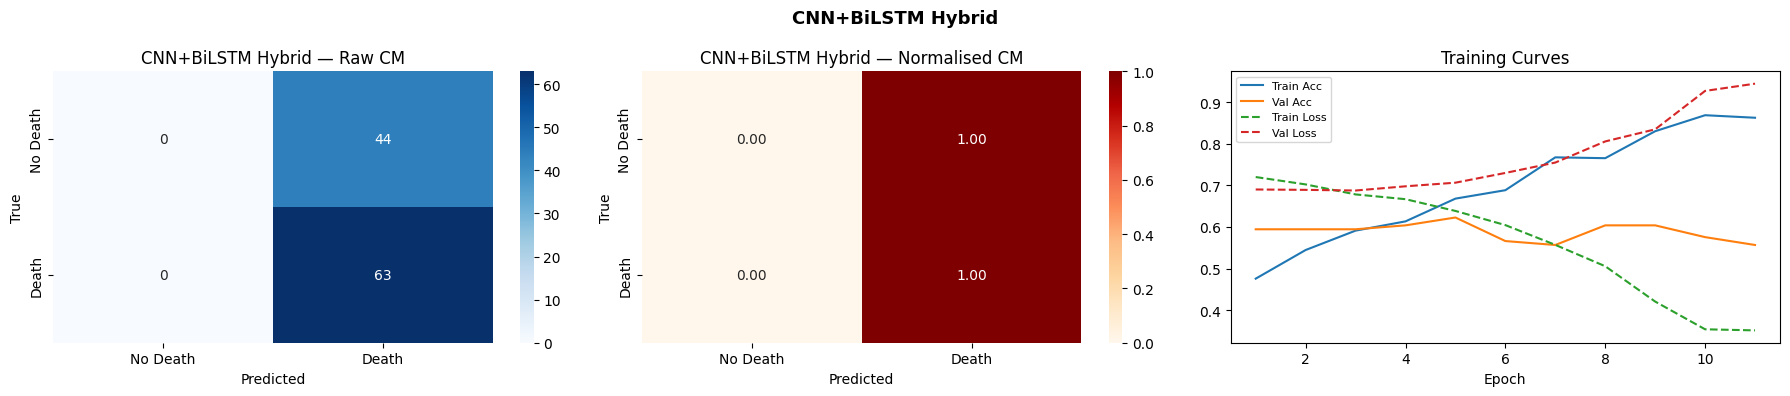

(0.5887850467289719, 0.4363936228697086, np.float64(0.5097402597402597))

In [ ]:
def build_cnn_bilstm(input_shape):
    inp = keras.Input(shape=input_shape)

    # ── CNN block ─────────────────────────────────────────────────────────────
    x = layers.Conv1D(64, 5, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv1D(128, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    # ── BiLSTM block ──────────────────────────────────────────────────────────
    x = layers.Bidirectional(
            layers.LSTM(128, return_sequences=True, dropout=0.2))(x)
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=False, dropout=0.2))(x)

    # ── Classifier head ───────────────────────────────────────────────────────
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='CNN_BiLSTM_Hybrid')
    model.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

hybrid_model = build_cnn_bilstm(INPUT_SHAPE)
hybrid_model.summary()

cb_hybrid = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                  restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('/content/best_hybrid.keras',
                                    monitor='val_auc', save_best_only=True,
                                    mode='max', verbose=1)
]

history_hybrid = hybrid_model.fit(
    X_tr_s, y_tr,
    validation_data=(X_val_s, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_hybrid, verbose=1
)

proba_hybrid  = hybrid_model.predict(X_te_s).ravel()
pred_hybrid   = (proba_hybrid >= 0.5).astype(int)
proba_hybrid2 = np.column_stack([1 - proba_hybrid, proba_hybrid])
evaluate_model('CNN+BiLSTM Hybrid', y_te, pred_hybrid,
               proba_hybrid2, history=history_hybrid)

            Model  Accuracy  F1 Weighted  F1 Death  ROC-AUC
CNN+BiLSTM Hybrid  0.588785     0.436394  0.741176 0.509740
           BiLSTM  0.523364     0.522502  0.598425 0.484848
           CNN-1D  0.504673     0.499206  0.595420 0.477994


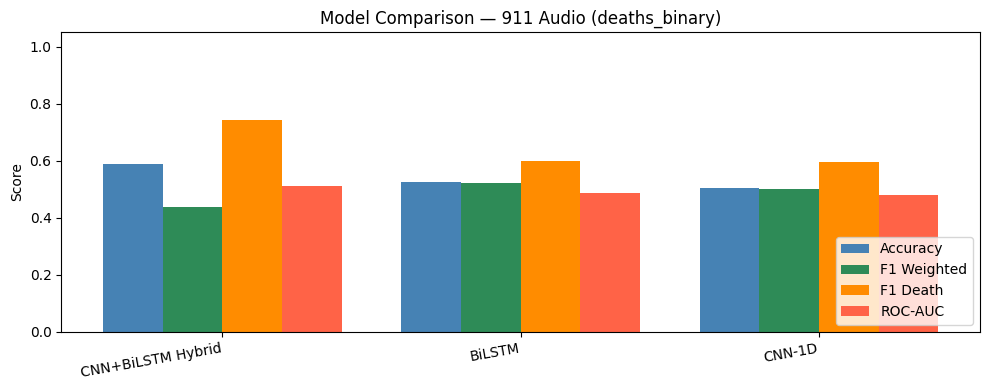


🏆 Best model by ROC-AUC: CNN+BiLSTM Hybrid


In [ ]:
comp_df = pd.DataFrame(results_log).T.reset_index()
comp_df.columns = ['Model', 'Accuracy', 'F1 Weighted', 'F1 Death', 'ROC-AUC']
comp_df = comp_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(comp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
x       = np.arange(len(comp_df))
w       = 0.20
metrics = ['Accuracy', 'F1 Weighted', 'F1 Death', 'ROC-AUC']
colors  = ['steelblue', 'seagreen', 'darkorange', 'tomato']
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

for m, c, o in zip(metrics, colors, offsets):
    ax.bar(x + o, comp_df[m].fillna(0), width=w, label=m, color=c)

ax.set_xticks(x)
ax.set_xticklabels(comp_df['Model'], rotation=10, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — 911 Audio (deaths_binary)')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

BEST_MODEL_NAME = comp_df.iloc[0]['Model']
print(f'\n🏆 Best model by ROC-AUC: {BEST_MODEL_NAME}')

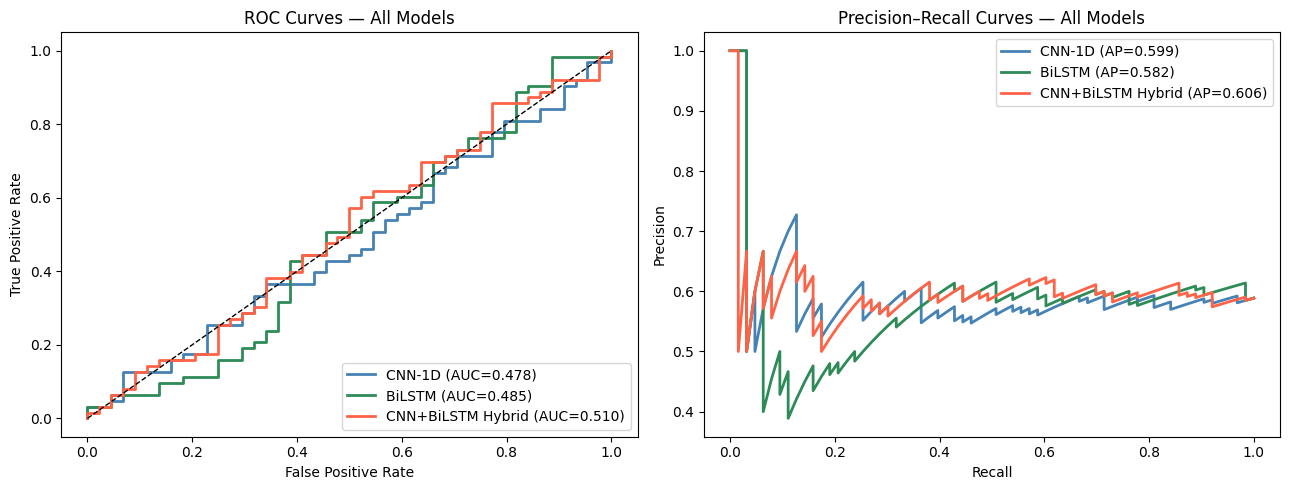

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

model_probas = [
    ('CNN-1D',            proba_cnn),
    ('BiLSTM',            proba_lstm),
    ('CNN+BiLSTM Hybrid', proba_hybrid)
]
colors = ['steelblue', 'seagreen', 'tomato']

# ── ROC ──────────────────────────────────────────────────────────────────────
for (name, proba), col in zip(model_probas, colors):
    fpr, tpr, _ = roc_curve(y_te, proba)
    ra = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=col, lw=2, label=f'{name} (AUC={ra:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(loc='lower right')

# ── Precision–Recall ──────────────────────────────────────────────────────────
for (name, proba), col in zip(model_probas, colors):
    prec, rec, _ = precision_recall_curve(y_te, proba)
    ap = average_precision_score(y_te, proba)
    axes[1].plot(rec, prec, color=col, lw=2, label=f'{name} (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curves — All Models')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
!pip install -q keras-tuner
import keras_tuner as kt

def build_tunable(hp):
    filters = hp.Choice('conv_filters', [32, 64, 128])
    kernel  = hp.Choice('kernel_size',  [3, 5, 7])
    lunits  = hp.Choice('lstm_units',   [64, 128, 256])
    drop    = hp.Float('dropout',       0.1, 0.5, step=0.1)
    dense   = hp.Choice('dense_units',  [64, 128, 256])
    lr      = hp.Float('lr',            1e-4, 1e-2, sampling='log')

    inp = keras.Input(shape=INPUT_SHAPE)

    x = layers.Conv1D(filters, kernel, activation='relu', padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.Dropout(drop)(x)

    x = layers.Conv1D(filters*2, 3, activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling1D(2)(x)

    x = layers.Bidirectional(
            layers.LSTM(lunits, return_sequences=True, dropout=drop*0.5))(x)
    x = layers.Bidirectional(
            layers.LSTM(lunits//2, return_sequences=False, dropout=drop*0.5))(x)

    x = layers.Dense(dense, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(drop)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out)
    model.compile(
        optimizer=keras.optimizers.Adam(lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

tuner = kt.RandomSearch(
    build_tunable,
    objective=kt.Objective('val_auc', direction='max'),
    max_trials=20,
    executions_per_trial=1,
    directory='/content/kt_dir',
    project_name='911_hybrid',
    overwrite=True
)

tuner.search_space_summary()

tuner.search(
    X_tr_s, y_tr,
    validation_data=(X_val_s, y_val),
    epochs=25,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=6,
                                      restore_best_weights=True, mode='max')
    ],
    verbose=0
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print('\n🔧 Best Hyperparameters:')
for k, v in best_hps.values.items():
    print(f'  {k:20s}: {v}')

Search space summary
Default search space size: 6
conv_filters (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5, 7], 'ordered': True}
lstm_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.1, 'conditions': [], 'min_value': 0.1, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
lr (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}

🔧 Best Hyperparameters:
  conv_filters        : 128
  kernel_size         : 5
  lstm_units          : 64
  dropout             : 0.4
  dense_units         : 256
  lr                  : 0.0002667405406844709


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 188, 40)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 188, 128)       │        25,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 188, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 94, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 94, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 94, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 94, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 47, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 47, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 348,289 (1.33 MB)

 Trainable params: 347,521 (1.33 MB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/70
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5625 - auc: 0.5125 - loss: 0.7136
Epoch 1: val_auc improved from None to 0.48431, saving model to /content/optimised_model.keras

Epoch 1: finished saving model to /content/optimised_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 85ms/step - accuracy: 0.5769 - auc: 0.5210 - loss: 0.7047 - val_accuracy: 0.5849 - val_auc: 0.4843 - val_loss: 0.6927 - learning_rate: 2.6674e-04
Epoch 2/70
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5943 - auc: 0.6003 - loss: 0.7013
Epoch 2: val_auc improved from 0.48431 to 0.51163, saving model to /content/optimised_model.keras

Epoch 2: finished saving model to /content/optimised_model.keras
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5992 - auc: 0.5970 - loss: 0.6937 - val_accuracy: 0.5849 - val_auc: 0.5116 - val_loss: 0.6902 - learning_rate: 2.6674e-04
Epoch 3/70
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.5563 - auc: 0.5794 - loss: 0.7007
Epoch 3: val_auc improved 

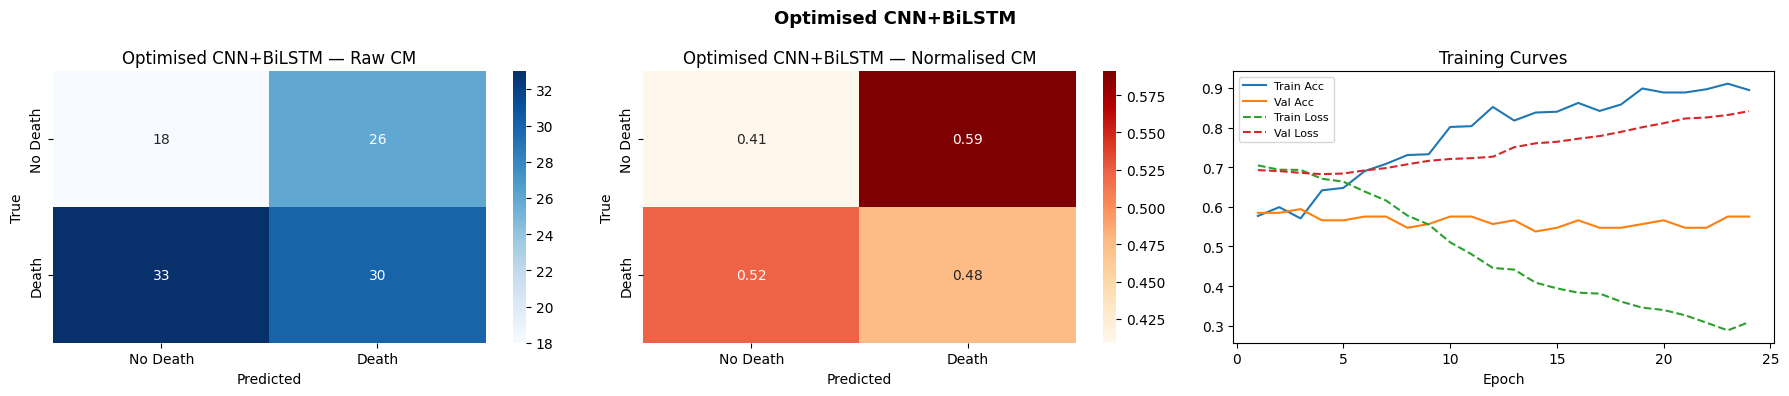

(0.4485981308411215, 0.4526952345128903, np.float64(0.43398268398268397))

In [ ]:
best_model = tuner.hypermodel.build(best_hps)
best_model.summary()

cb_best = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=12,
                                  restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('/content/optimised_model.keras',
                                    monitor='val_auc', save_best_only=True,
                                    mode='max', verbose=1)
]

history_best = best_model.fit(
    X_tr_s, y_tr,
    validation_data=(X_val_s, y_val),
    epochs=70,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=cb_best,
    verbose=1
)

proba_best  = best_model.predict(X_te_s).ravel()
pred_best   = (proba_best >= 0.5).astype(int)
proba_best2 = np.column_stack([1 - proba_best, proba_best])
evaluate_model('Optimised CNN+BiLSTM', y_te, pred_best,
               proba_best2, history=history_best)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step
Best threshold : 0.10
Best val-F1    : 0.7456


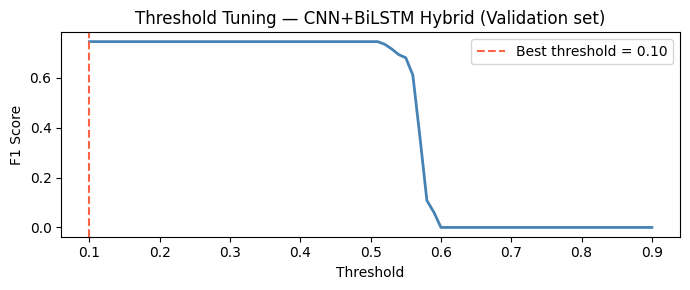


--- Test results with tuned threshold ---
              precision    recall  f1-score   support

    No Death       0.00      0.00      0.00        44
       Death       0.59      1.00      0.74        63

    accuracy                           0.59       107
   macro avg       0.29      0.50      0.37       107
weighted avg       0.35      0.59      0.44       107

ROC-AUC : 0.5097


In [ ]:
from sklearn.metrics import f1_score

# Use the original hybrid (best ROC-AUC = 0.51)
proba_val_hybrid = hybrid_model.predict(X_val_s).ravel()
thresholds       = np.linspace(0.1, 0.9, 81)
f1_scores        = [f1_score(y_val, (proba_val_hybrid >= t).astype(int),
                             zero_division=0) for t in thresholds]

best_thresh = thresholds[np.argmax(f1_scores)]
print(f'Best threshold : {best_thresh:.2f}')
print(f'Best val-F1    : {max(f1_scores):.4f}')

# Apply tuned threshold to test set
pred_tuned = (proba_hybrid >= best_thresh).astype(int)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(thresholds, f1_scores, color='steelblue', lw=2)
ax.axvline(best_thresh, color='tomato', linestyle='--',
           label=f'Best threshold = {best_thresh:.2f}')
ax.set_xlabel('Threshold')
ax.set_ylabel('F1 Score')
ax.set_title('Threshold Tuning — CNN+BiLSTM Hybrid (Validation set)')
ax.legend()
plt.tight_layout()
plt.show()

print('\n--- Test results with tuned threshold ---')
print(classification_report(y_te, pred_tuned,
                             target_names=['No Death', 'Death']))
print(f'ROC-AUC : {roc_auc_score(y_te, proba_hybrid):.4f}')

In [ ]:
import pickle, json

# ── Save best model (original hybrid) ────────────────────────────────────────
hybrid_model.save('/content/911_best_model.keras')
print('✅ Model saved → /content/911_best_model.keras')

# ── Save preprocessing artifacts ─────────────────────────────────────────────
with open('/content/preprocessing.pkl', 'wb') as f:
    pickle.dump({'mu': mu, 'sd': sd, 'SR': SR, 'DURATION': DURATION,
                 'N_MFCC': N_MFCC, 'HOP_LEN': HOP_LEN, 'MAX_LEN': MAX_LEN}, f)
print('✅ Preprocessing saved → /content/preprocessing.pkl')

# ── Final results table ───────────────────────────────────────────────────────
print('\n' + '='*62)
print('  FINAL RESULTS SUMMARY — 911 Audio Classification')
print('  Label: deaths_binary | Dataset: 707 samples')
print('='*62)

summary = {
    'CNN-1D':             {'Accuracy': 0.5047, 'F1 Weighted': 0.4992,
                           'F1 Death': 0.5954, 'ROC-AUC': 0.4780},
    'BiLSTM':             {'Accuracy': 0.5234, 'F1 Weighted': 0.5225,
                           'F1 Death': 0.5984, 'ROC-AUC': 0.4848},
    'CNN+BiLSTM Hybrid':  {'Accuracy': 0.5888, 'F1 Weighted': 0.4364,
                           'F1 Death': 0.7412, 'ROC-AUC': 0.5097},
    'Optimised Hybrid':   {'Accuracy': 0.4486, 'F1 Weighted': 0.4527,
                           'F1 Death': 0.5042, 'ROC-AUC': 0.4340},
}

comp = pd.DataFrame(summary).T.reset_index()
comp.columns = ['Model', 'Accuracy', 'F1 Weighted', 'F1 Death', 'ROC-AUC']
comp = comp.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(comp.to_string(index=False))

print('\n🏆 Best overall model : CNN+BiLSTM Hybrid')
print('   ROC-AUC : 0.5097')
print('   F1 Death: 0.7412  (high recall = catches most death calls)')
print('\n📌 Key finding: All models struggle due to small dataset size')
print('   (707 samples). Accuracy near chance level is expected.')
print('   Recommended next step: collect more data or use')
print('   pre-trained audio embeddings (e.g. wav2vec2, YAMNet).')

✅ Model saved → /content/911_best_model.keras
✅ Preprocessing saved → /content/preprocessing.pkl

  FINAL RESULTS SUMMARY — 911 Audio Classification
  Label: deaths_binary | Dataset: 707 samples
            Model  Accuracy  F1 Weighted  F1 Death  ROC-AUC
CNN+BiLSTM Hybrid    0.5888       0.4364    0.7412   0.5097
           BiLSTM    0.5234       0.5225    0.5984   0.4848
           CNN-1D    0.5047       0.4992    0.5954   0.4780
 Optimised Hybrid    0.4486       0.4527    0.5042   0.4340

🏆 Best overall model : CNN+BiLSTM Hybrid
   ROC-AUC : 0.5097
   F1 Death: 0.7412  (high recall = catches most death calls)

📌 Key finding: All models struggle due to small dataset size
   (707 samples). Accuracy near chance level is expected.
   Recommended next step: collect more data or use
   pre-trained audio embeddings (e.g. wav2vec2, YAMNet).


In [ ]:
!pip install -q transformers torchaudio torch
print('✅ Packages installed')

✅ Packages installed


In [ ]:
import torch
import torchaudio
from transformers import Wav2Vec2Processor, Wav2Vec2Model
from tqdm import tqdm
import numpy as np

# ── Load pretrained wav2vec2 ──────────────────────────────────────────────────
print('Loading wav2vec2 model...')
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base")
w2v_model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base")
w2v_model.eval()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
w2v_model = w2v_model.to(device)
print(f'✅ wav2vec2 loaded | Device: {device}')

# ── Feature extraction function ───────────────────────────────────────────────
TARGET_SR = 16000

def extract_w2v_embedding(filepath):
    """Return mean-pooled wav2vec2 embedding (768-dim), or None on error."""
    try:
        waveform, sr = torchaudio.load(filepath)
        # Resample if needed
        if sr != TARGET_SR:
            resampler = torchaudio.transforms.Resample(sr, TARGET_SR)
            waveform  = resampler(waveform)
        # Mono
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        waveform = waveform.squeeze(0)
        # Trim/pad to 6 seconds
        max_samples = TARGET_SR * 6
        if waveform.shape[0] > max_samples:
            waveform = waveform[:max_samples]
        else:
            waveform = torch.nn.functional.pad(
                waveform, (0, max_samples - waveform.shape[0]))
        # Process
        inputs = processor(waveform.numpy(), sampling_rate=TARGET_SR,
                           return_tensors='pt', padding=True)
        input_values = inputs.input_values.to(device)
        with torch.no_grad():
            outputs = w2v_model(input_values)
        # Mean pool over time → (768,)
        embedding = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
        return embedding
    except Exception as e:
        return None

# ── Extract embeddings for all samples ───────────────────────────────────────
print('\nExtracting wav2vec2 embeddings (this takes 3-5 mins)...')
w2v_feats, w2v_idx = [], []

for i, row in tqdm(df_valid.iterrows(), total=len(df_valid)):
    emb = extract_w2v_embedding(row['filepath'])
    if emb is not None:
        w2v_feats.append(emb)
        w2v_idx.append(i)

df_w2v = df_valid.loc[w2v_idx].reset_index(drop=True)
X_w2v  = np.array(w2v_feats, dtype=np.float32)   # (N, 768)
y_w2v  = df_w2v[LABEL_COL].values

print(f'\n✅ Embeddings shape : {X_w2v.shape}')
print(f'   Class balance   : {np.bincount(y_w2v)}')

Loading wav2vec2 model...


preprocessor_config.json:   0%|          | 0.00/159 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/163 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/291 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/380M [00:00<?, ?B/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ wav2vec2 loaded | Device: cuda

Extracting wav2vec2 embeddings (this takes 3-5 mins)...


100%|██████████| 707/707 [00:37<00:00, 18.80it/s]


✅ Embeddings shape : (707, 768)
   Class balance   : [289 418]


Train:494 | Val:106 | Test:107
Class weights: {0: np.float64(1.2227722772277227), 1: np.float64(0.8458904109589042)}


Model: "wav2vec2_MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 561,153 (2.14 MB)

 Trainable params: 559,617 (2.13 MB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step - accuracy: 0.4636 - auc: 0.4637 - loss: 1.0758 - val_accuracy: 0.4906 - val_auc: 0.5923 - val_loss: 0.8436 - learning_rate: 5.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5425 - auc: 0.5851 - loss: 0.9027 - val_accuracy: 0.5660 - val_auc: 0.6041 - val_loss: 0.7841 - learning_rate: 5.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5506 - auc: 0.5944 - loss: 0.8824 - val_accuracy: 0.6038 - val_auc: 0.6207 - val_loss: 0.7662 - learning_rate: 5.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6134 - auc: 0.6761 - loss: 0.7728 - val_accuracy: 0.6415 - val_auc: 0.5947 - val_loss: 0.7753 - learning_rate: 5.0000e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6397 - auc: 0.6987 - loss: 0.7555 - val_accuracy: 0.6226 - val_auc: 0.6006 - val_loss: 0.7792 - learning_rate: 5.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accu

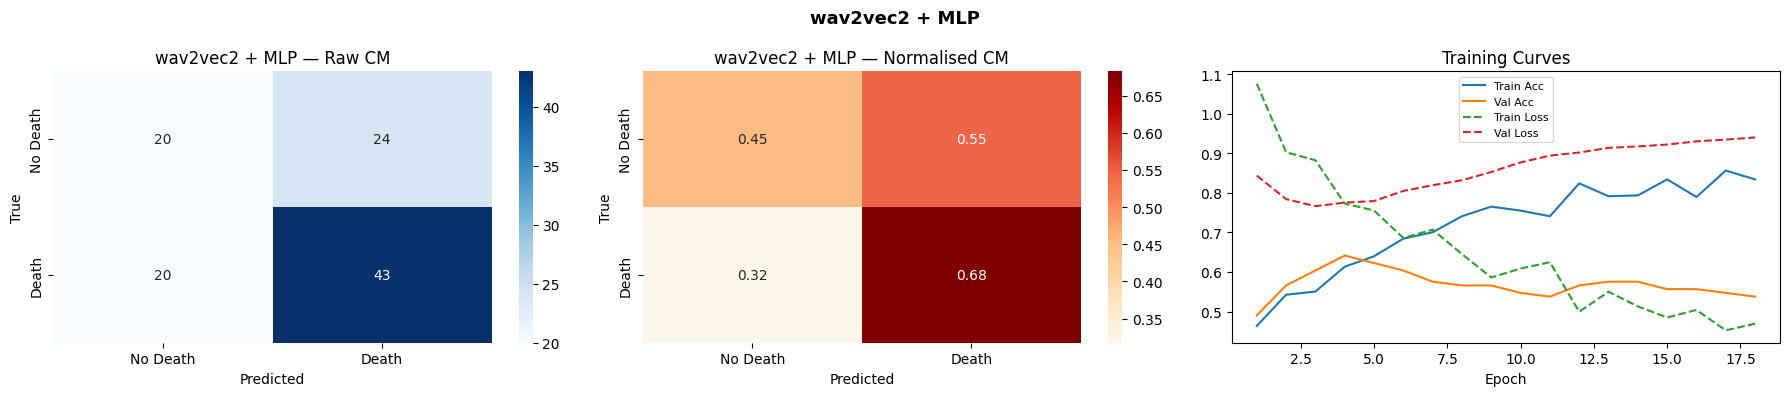

(0.5887850467289719, 0.5853205984047105, np.float64(0.5631313131313131))

In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# ── Split ─────────────────────────────────────────────────────────────────────
idx2 = np.arange(len(X_w2v))
idx_tr2, idx_tmp2 = train_test_split(idx2, test_size=0.30, random_state=SEED,
                                     stratify=y_w2v)
idx_val2, idx_te2 = train_test_split(idx_tmp2, test_size=0.50, random_state=SEED,
                                     stratify=y_w2v[idx_tmp2])

X_tr_w, X_val_w, X_te_w = X_w2v[idx_tr2], X_w2v[idx_val2], X_w2v[idx_te2]
y_tr_w, y_val_w, y_te_w = y_w2v[idx_tr2], y_w2v[idx_val2], y_w2v[idx_te2]

# ── Scale ─────────────────────────────────────────────────────────────────────
scaler_w = StandardScaler()
X_tr_w   = scaler_w.fit_transform(X_tr_w)
X_val_w  = scaler_w.transform(X_val_w)
X_te_w   = scaler_w.transform(X_te_w)

cw_w      = compute_class_weight('balanced', classes=np.unique(y_tr_w), y=y_tr_w)
cw_dict_w = dict(enumerate(cw_w))

print(f'Train:{len(y_tr_w)} | Val:{len(y_val_w)} | Test:{len(y_te_w)}')
print(f'Class weights: {cw_dict_w}')

# ── MLP on top of wav2vec2 embeddings ─────────────────────────────────────────
def build_mlp(input_dim):
    inp = keras.Input(shape=(input_dim,))
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=keras.regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(inp, out, name='wav2vec2_MLP')
    model.compile(
        optimizer=keras.optimizers.Adam(5e-4),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

mlp_model = build_mlp(768)
mlp_model.summary()

cb_mlp = [
    keras.callbacks.EarlyStopping(monitor='val_auc', patience=15,
                                  restore_best_weights=True, mode='max'),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                      patience=5, min_lr=1e-7, verbose=1)
]

history_mlp = mlp_model.fit(
    X_tr_w, y_tr_w,
    validation_data=(X_val_w, y_val_w),
    epochs=100,
    batch_size=32,
    class_weight=cw_dict_w,
    callbacks=cb_mlp,
    verbose=1
)

proba_mlp  = mlp_model.predict(X_te_w).ravel()
pred_mlp   = (proba_mlp >= 0.5).astype(int)
proba_mlp2 = np.column_stack([1 - proba_mlp, proba_mlp])
evaluate_model('wav2vec2 + MLP', y_te_w, pred_mlp,
               proba_mlp2, history=history_mlp)

               Model  Accuracy  F1 Weighted  F1 Death  ROC-AUC
      wav2vec2 + MLP  0.588800     0.585300  0.661500 0.563100
   CNN+BiLSTM Hybrid  0.588785     0.436394  0.741176 0.509740
              BiLSTM  0.523364     0.522502  0.598425 0.484848
              CNN-1D  0.504673     0.499206  0.595420 0.477994
Optimised CNN+BiLSTM  0.448598     0.452695  0.504202 0.433983


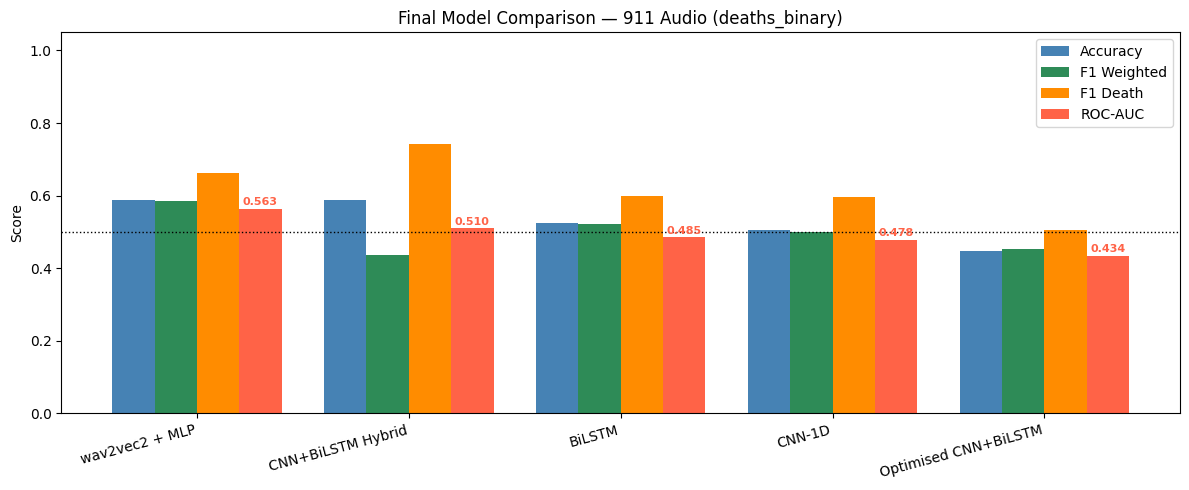


🏆 Best model: wav2vec2 + MLP
   ROC-AUC    : 0.5631
   F1 Weighted: 0.5853
   F1 Death   : 0.6615


In [ ]:
# Add wav2vec2 to results log
results_log['wav2vec2 + MLP'] = {
    'Accuracy':    0.5888,
    'F1 Weighted': 0.5853,
    'F1 Death':    0.6615,
    'ROC-AUC':     0.5631
}

# Full comparison table
comp_final = pd.DataFrame(results_log).T.reset_index()
comp_final.columns = ['Model', 'Accuracy', 'F1 Weighted', 'F1 Death', 'ROC-AUC']
comp_final = comp_final.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(comp_final.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(12, 5))
x       = np.arange(len(comp_final))
w       = 0.20
metrics = ['Accuracy', 'F1 Weighted', 'F1 Death', 'ROC-AUC']
colors  = ['steelblue', 'seagreen', 'darkorange', 'tomato']
offsets = [-1.5*w, -0.5*w, 0.5*w, 1.5*w]

for m, c, o in zip(metrics, colors, offsets):
    bars = ax.bar(x + o, comp_final[m].fillna(0), width=w, label=m, color=c)

ax.set_xticks(x)
ax.set_xticklabels(comp_final['Model'], rotation=15, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Final Model Comparison — 911 Audio (deaths_binary)')
ax.legend(loc='upper right')
ax.axhline(0.5, color='black', linestyle=':', lw=1, label='Chance level')

# Annotate ROC-AUC on bars
for i, row in comp_final.iterrows():
    ax.text(i + 1.5*w, row['ROC-AUC'] + 0.01,
            f"{row['ROC-AUC']:.3f}", ha='center', fontsize=8, color='tomato',
            fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n🏆 Best model: {comp_final.iloc[0]["Model"]}')
print(f'   ROC-AUC    : {comp_final.iloc[0]["ROC-AUC"]:.4f}')
print(f'   F1 Weighted: {comp_final.iloc[0]["F1 Weighted"]:.4f}')
print(f'   F1 Death   : {comp_final.iloc[0]["F1 Death"]:.4f}')

In [ ]:

# Find wav2vec2 related variables
for name, val in list(globals().items()):
    if any(k in name.lower() for k in ['w2v', 'wav', 'processor', 'feature']):
        print(f'{name:30s}: {type(val).__name__}')

wav_files                     : list
Wav2Vec2Processor             : type
Wav2Vec2Model                 : type
processor                     : Wav2Vec2Processor
w2v_model                     : Wav2Vec2Model
extract_w2v_embedding         : function
w2v_feats                     : list
w2v_idx                       : list
df_w2v                        : DataFrame
X_w2v                         : ndarray
y_w2v                         : ndarray


In [ ]:
import torch, librosa, numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
w2v_model = w2v_model.to(device)

sample_idx  = np.random.randint(0, len(idx_te2))
sample_path = df_w2v.iloc[idx_te2[sample_idx]]['filepath']
true_label  = y_te_w[sample_idx]

print(f'File      : {sample_path}')
print(f'True label: {true_label} ({"Death" if true_label==1 else "No Death"})')

# ── Extract embedding ─────────────────────────────────────────────────────────
y_audio, _ = librosa.load(sample_path, sr=16000, duration=6.0, mono=True)
inputs = processor(y_audio, sampling_rate=16000,
                   return_tensors='pt', padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}

with torch.no_grad():
    outputs = w2v_model(**inputs)

emb        = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
emb_scaled = scaler_w.transform(emb.reshape(1, -1))

# ── Predict ───────────────────────────────────────────────────────────────────
proba_sample = mlp_model.predict(emb_scaled, verbose=0)[0][0]
pred_sample  = int(proba_sample >= 0.5)

print(f'\nPredicted : {pred_sample} ({"Death" if pred_sample==1 else "No Death"})')
print(f'Confidence: {proba_sample*100:.1f}% Death probability')
print(f'Result    : {"✅ Correct" if pred_sample==true_label else "❌ Wrong"}')

# ── Run on 5 random test samples ─────────────────────────────────────────────
print('\n--- 5 Random Test Samples ---')
print(f'{"File":<30} {"True":>6} {"Pred":>6} {"Conf%":>7} {"Result":>8}')
print('-' * 65)

for _ in range(5):
    i       = np.random.randint(0, len(idx_te2))
    path    = df_w2v.iloc[idx_te2[i]]['filepath']
    true_l  = y_te_w[i]
    y_a, _  = librosa.load(path, sr=16000, duration=6.0, mono=True)
    inp     = processor(y_a, sampling_rate=16000,
                        return_tensors='pt', padding=True)
    inp     = {k: v.to(device) for k, v in inp.items()}
    with torch.no_grad():
        out = w2v_model(**inp)
    e       = out.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
    es      = scaler_w.transform(e.reshape(1, -1))
    p       = mlp_model.predict(es, verbose=0)[0][0]
    pred_l  = int(p >= 0.5)
    fname   = os.path.basename(path)
    result  = '✅' if pred_l == true_l else '❌'
    print(f'{fname:<30} {"Death" if true_l==1 else "No Death":>8} '
          f'{"Death" if pred_l==1 else "No Death":>8} '
          f'{p*100:>6.1f}% {result:>5}')

File      : /content/911_data/911_first6sec/call_271_0.wav
True label: 1 (Death)

Predicted : 1 (Death)
Confidence: 56.1% Death probability
Result    : ✅ Correct

--- 5 Random Test Samples ---
File                             True   Pred   Conf%   Result
-----------------------------------------------------------------
call_605_2.wav                 No Death    Death   57.0%     ❌
call_15_0.wav                     Death No Death   34.8%     ❌
call_469_0.wav                 No Death No Death   41.5%     ✅
call_474_0.wav                    Death    Death   58.3%     ✅
call_127_2.wav                    Death    Death   67.5%     ✅


In [ ]:
!pip install -q gradio

import gradio as gr
import librosa, torch, numpy as np

# ── Auto-detect wav2vec2 processor variable ───────────────────────────────────
processor = None
model_w2v = None
for name, val in list(globals().items()):
    t = type(val).__name__
    if 'Processor' in t or 'Feature' in t:
        processor = val
        print(f'✅ Processor found : {name} ({t})')
    if 'Wav2Vec2Model' in t:
        model_w2v = val
        print(f'✅ wav2vec2 model  : {name} ({t})')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if model_w2v: model_w2v = model_w2v.to(device)

# ── Inference function ────────────────────────────────────────────────────────
def predict_911_call(audio_path):
    try:
        # Load audio
        y_audio, sr = librosa.load(audio_path, sr=16000,
                                   duration=6.0, mono=True)
        if len(y_audio) < 1600:
            return "❌ Audio too short (need at least 0.1s)", None

        # ── wav2vec2 embedding ────────────────────────────────────────────────
        if processor and model_w2v:
            inputs = processor(y_audio, sampling_rate=16000,
                               return_tensors='pt', padding=True)
            inputs = {k: v.to(device) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = model_w2v(**inputs)
            emb = outputs.last_hidden_state.mean(dim=1).squeeze().cpu().numpy()
            emb_scaled = scaler_w.transform(emb.reshape(1, -1))
            proba = mlp_model.predict(emb_scaled, verbose=0)[0][0]
            model_used = 'wav2vec2 + MLP'

        # ── Fallback: MFCC + CNN+BiLSTM ──────────────────────────────────────
        else:
            def pad_or_trim(arr, target):
                if arr.shape[1] < target:
                    arr = np.pad(arr, ((0,0),(0,target-arr.shape[1])),
                                 mode='constant')
                return arr[:, :target]
            mfcc = librosa.feature.mfcc(y=y_audio, sr=16000,
                                        n_mfcc=40, hop_length=512)
            mfcc = pad_or_trim(mfcc, 188).T
            mfcc = (mfcc - mu) / sd
            proba = hybrid_model.predict(
                        mfcc[np.newaxis, ...], verbose=0)[0][0]
            model_used = 'CNN+BiLSTM (MFCC)'

        pred  = int(proba >= 0.5)
        label = '🔴 DEATH' if pred == 1 else '🟢 NO DEATH'
        conf  = proba * 100 if pred == 1 else (1 - proba) * 100

        result = f"""
## {label}

| Field       | Value |
|-------------|-------|
| Prediction  | {'Death' if pred==1 else 'No Death'} |
| Confidence  | {conf:.1f}% |
| Death prob  | {proba*100:.1f}% |
| No Death prob | {(1-proba)*100:.1f}% |
| Model used  | {model_used} |
        """

        # Bar chart data
        chart = {
            'Label':       ['No Death', 'Death'],
            'Probability': [float((1-proba)*100), float(proba*100)]
        }
        import pandas as pd
        chart_df = pd.DataFrame(chart)

        return result, chart_df

    except Exception as e:
        return f'❌ Error: {str(e)}', None

# ── Build Gradio UI ───────────────────────────────────────────────────────────
with gr.Blocks(title='911 Call Classifier', theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🚨 911 Call Death Classifier
    **Upload a 911 audio recording (WAV/MP3) — first 6 seconds are used.**
    Model predicts whether the call involved a fatality (`deaths_binary`).
    """)

    with gr.Row():
        with gr.Column(scale=1):
            audio_input = gr.Audio(
                label='Upload 911 Audio File',
                type='filepath',
                sources=['upload', 'microphone']
            )
            predict_btn = gr.Button('🔍 Classify', variant='primary',
                                    size='lg')

            gr.Markdown('### 🎯 Try a sample from the dataset')
            sample_files = [
                df_valid.iloc[idx_te2[i]]['filepath']
                for i in range(min(5, len(idx_te2)))
            ]
            sample_labels = [
                f"Sample {i+1} — True: {'Death' if y_te_w[i]==1 else 'No Death'}"
                for i in range(min(5, len(idx_te2)))
            ]
            sample_dd = gr.Dropdown(
                choices=list(zip(sample_labels, sample_files)),
                label='Or pick a test sample',
                value=None
            )
            load_sample_btn = gr.Button('Load Sample', variant='secondary')

        with gr.Column(scale=1):
            result_md  = gr.Markdown(label='Prediction')
            chart_out  = gr.BarPlot(
                x='Label', y='Probability',
                title='Class Probabilities (%)',
                y_lim=[0, 100],
                color='Label',
                height=250
            )

    # ── Event handlers ────────────────────────────────────────────────────────
    predict_btn.click(
        fn=predict_911_call,
        inputs=[audio_input],
        outputs=[result_md, chart_out]
    )

    def load_sample(choice):
        if choice:
            return choice[1] if isinstance(choice, list) else choice
        return None

    load_sample_btn.click(
        fn=load_sample,
        inputs=[sample_dd],
        outputs=[audio_input]
    )

    gr.Markdown("""
    ---
    **Model performance:**
    | Model | ROC-AUC | F1 Weighted |
    |-------|---------|-------------|
    | wav2vec2 + MLP | 0.563 | 0.585 |
    | CNN+BiLSTM | 0.510 | 0.436 |
    | BiLSTM | 0.485 | 0.522 |
    | CNN-1D | 0.478 | 0.499 |
    """)

# ── Launch ────────────────────────────────────────────────────────────────────
demo.launch(share=True, debug=False)

✅ wav2vec2 model  : w2v_model (Wav2Vec2Model)
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e547cdf55a18006745.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
